In [1]:
from pathlib import Path
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
data_folder = Path("DD_data")
mat_files = sorted(data_folder.glob("*.mat"))

In [3]:
# get columns of the dataframes
data_0 = loadmat(mat_files[0])
data_labels = data_0["data_labels"]
columns = [label[0] for label in data_labels[0]]

print(columns)

['immOutcome', 'delOutcome', 'delay', 'action (1=immediate, 2=delayed, 0=missing)', 'p_imm', 'condition (1=reward,2=loss)', 'RT']


In [4]:
# convert data to dataframes
participants = []

for file in mat_files:
    data = loadmat(file)

    train_df = pd.DataFrame(data["data_train"], columns=columns)
    test_df = pd.DataFrame(data["data_test"], columns=columns)

    participants.append({
        "train": train_df,
        "test": test_df
    })

In [5]:
participants[0]["train"]

,immOutcome,delOutcome,delay,"action (1=immediate, 2=delayed, 0=missing)",p_imm,"condition (1=reward,2=loss)",RT
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5
...,...,...,...,...,...,...,...
75,48.54,50.0,30.0,1.0,0.5,1.0,3756.2
76,4.59,5.0,90.0,1.0,0.5,1.0,1209.4
77,10.53,20.0,90.0,1.0,0.5,1.0,2396.9
78,9.99,10.0,90.0,1.0,0.5,1.0,1274.4


In [6]:
participants[0]["test"]

,immOutcome,delOutcome,delay,"action (1=immediate, 2=delayed, 0=missing)",p_imm,"condition (1=reward,2=loss)",RT
0,4.91,20.0,365.0,1.0,0.5,1.0,1507.5
1,23.27,50.0,90.0,1.0,0.7,1.0,1260.5
2,2.55,20.0,90.0,2.0,0.2,1.0,2113.5
3,15.90,50.0,180.0,1.0,0.5,1.0,1764.1
4,16.18,20.0,30.0,2.0,0.8,1.0,1984.3
...,...,...,...,...,...,...,...
175,16.64,50.0,90.0,1.0,0.3,1.0,1741.6
176,4.99,5.0,365.0,2.0,0.8,1.0,1405.7
177,7.88,10.0,365.0,1.0,0.8,1.0,1249.0
178,3.58,5.0,90.0,1.0,0.6,1.0,2584.1


In [7]:
# check missing and invalid data for all participants for later cleaning

# missing action
action_zero = 0

# missing immediate reward
imm_nan = 0

# missing delayed reward
del_nan = 0

# missing delay
delay_nan = 0

# missing condition
condition_nan = 0

# loss discounting condition
condition_loss = 0

# missing RT
rt_nan = 0

# non-positive RT
rt_nonpositive = 0

for participant in participants:
    for run in ["train", "test"]:
        df = participant[run]

        action_zero += (df["action (1=immediate, 2=delayed, 0=missing)"] == 0).sum()

        imm_nan += df["immOutcome"].isna().sum()
        del_nan += df["delOutcome"].isna().sum()
        delay_nan += df["delay"].isna().sum()
        condition_nan += df["condition (1=reward,2=loss)"].isna().sum()
        condition_loss += (df["condition (1=reward,2=loss)"] == 2).sum()
        rt_nan += df["RT"].isna().sum()

        rt_nonpositive += (df["RT"] <= 0).sum()

print("action = 0:", action_zero)
print("immOutcome NaN:", imm_nan)
print("delOutcome NaN:", del_nan)
print("delay NaN:", delay_nan)
print("condition NaN:", condition_nan)
print("condition (2=loss):", condition_loss)
print("RT NaN:", rt_nan)
print("RT <= 0:", rt_nonpositive)


action = 0: 93
immOutcome NaN: 60
delOutcome NaN: 0
delay NaN: 0
condition NaN: 0
condition (2=loss): 0
RT NaN: 93
RT <= 0: 0


In [8]:
# This is the cleaned data that will be used for analysis.

cleaned_data = []

In [9]:
# record how many rows are deleted from each run
deleted_train = 0
deleted_test = 0

for i, participant in enumerate(participants):

    train_df = participant["train"].copy()
    test_df = participant["test"].copy()

    original_train = len(train_df)
    original_test = len(test_df)

    # remove missing choices
    train_df = train_df[
        train_df["action (1=immediate, 2=delayed, 0=missing)"] != 0
    ]

    test_df = test_df[
        test_df["action (1=immediate, 2=delayed, 0=missing)"] != 0
    ]

    # remove NaNs
    nan_columns = [
        "immOutcome",
        "delOutcome",
        "delay",
        "action (1=immediate, 2=delayed, 0=missing)",
        "condition (1=reward,2=loss)",
        "RT"
    ]

    train_df = train_df.dropna(subset=nan_columns).copy()
    test_df = test_df.dropna(subset=nan_columns).copy()

    # create binary choice
    train_df["action(cleaned)"] = (
        train_df["action (1=immediate, 2=delayed, 0=missing)"] == 1
    ).astype(int)

    test_df["action(cleaned)"] = (
        test_df["action (1=immediate, 2=delayed, 0=missing)"] == 1
    ).astype(int)

    deleted_train += original_train - len(train_df)
    deleted_test += original_test - len(test_df)

    cleaned_data.append({
        "participant_id": i + 1,
        "train": train_df,
        "test": test_df
    })

print("deleted from Train:", deleted_train)
print("deleted from Test:", deleted_test)

deleted from Train: 34
deleted from Test: 118


In [10]:
# check missing and invalid data for all participants

action_zero = 0
imm_nan = 0
del_nan = 0
delay_nan = 0
action_nan = 0
condition_nan = 0
rt_nan = 0
rt_nonpositive = 0

for participant in cleaned_data:
    for run in ["train", "test"]:
        df = participant[run]

        action_zero += (df["action (1=immediate, 2=delayed, 0=missing)"] == 0).sum()

        imm_nan += df["immOutcome"].isna().sum()
        del_nan += df["delOutcome"].isna().sum()
        delay_nan += df["delay"].isna().sum()
        action_nan += df["action (1=immediate, 2=delayed, 0=missing)"].isna().sum()
        condition_nan += df["condition (1=reward,2=loss)"].isna().sum()
        rt_nan += df["RT"].isna().sum()

print("action = 0:", action_zero)
print("immOutcome NaN:", imm_nan)
print("delOutcome NaN:", del_nan)
print("delay NaN:", delay_nan)
print("action NaN:", action_nan)
print("condition NaN:", condition_nan)
print("RT NaN:", rt_nan)


action = 0: 0
immOutcome NaN: 0
delOutcome NaN: 0
delay NaN: 0
action NaN: 0
condition NaN: 0
RT NaN: 0


In [11]:
cleaned_data[0]["train"].head()

,immOutcome,delOutcome,delay,"action (1=immediate, 2=delayed, 0=missing)",p_imm,"condition (1=reward,2=loss)",RT,action(cleaned)
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,1
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,1
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,1
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,0
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,0


## Valuation and choice model

I use a hyperbolic discounting model. The delayed value on trial
$i$ is

$$
V_{del,i} = \frac{r_{del,i}}{1 + kD_i}.
$$

The immediate reward is not discounted:

$$
V_{imm,i} = r_{imm,i}.
$$

I define the value difference as

$$
\Delta V_i = V_{imm,i} - V_{del,i}.
$$

A positive value of $\Delta V_i$ therefore favours the immediate
option. In the report, this value difference is referred to as the
drift-rate prior.

In [12]:
# Hyperbolic valuation function
def hyperbolic_value(imm_outcome, del_outcome, delay, k):
    v_imm = imm_outcome
    v_del = del_outcome / (1 + k * delay)
    v_delta = v_imm - v_del

    return v_imm, v_del, v_delta

### Logistic choice rule

The probability of choosing the immediate option is given by a
logistic choice rule:

$$
P(x_i = 1) =
\frac{1}{1 + \exp(-\beta \Delta V_i)}.
$$

Here, $x_i = 1$ represents an immediate choice and $x_i = 0$
represents a delayed choice. The parameter $\beta$ controls how
strongly choices follow the value difference.

In [13]:
def logistic_choice(v_delta, beta):
    p_imm = 1 / (1 + np.exp(-beta * v_delta))
    p_del = 1 - p_imm

    return p_imm, p_del

## RT models

RT is measured in milliseconds. I assume that log RT is normally
distributed:

$$
\log(RT_i) \sim \mathcal{N}(\mu_i, \sigma^2).
$$

The three RT models use the same log-normal distribution but define the mean of log RT, mu_i, differently
Absolute mapping:

$$
\mu_i = a - b|\Delta V_i|.
$$

Squared mapping:

$$
\mu_i = a - b(\Delta V_i)^2.
$$

Exponential mapping:

$$
\mu_i = a + b\exp\left(-(\Delta V_i)^2\right).
$$

All three mappings predict slower responses near indifference, but
they differ in how quickly predicted RT changes as the two option
values move apart.

In [14]:
def rt_location(v_delta, a, b, rt_model):
    if rt_model == "absolute":
        mu_rt = a - b * np.abs(v_delta)

    elif rt_model == "squared":
        mu_rt = a - b * (v_delta**2)

    elif rt_model == "exponential":
        mu_rt = a + b * np.exp(-(v_delta**2))

    else:
        raise ValueError(f"Unknown RT model: {rt_model}")

    return mu_rt

In [15]:
data = cleaned_data[0]["train"]

print(data["RT"].describe())
print(data["immOutcome"].describe())
print(data["delOutcome"].describe())
print(data["delay"].describe())

count      79.000000
mean     2117.945570
std      1143.310054
min      1004.800000
25%      1403.800000
50%      1782.500000
75%      2213.450000
max      6617.900000
Name: RT, dtype: float64
count    79.000000
mean     13.394557
std      15.587671
min       0.020000
25%       2.390000
50%       7.690000
75%      19.055000
max      49.990000
Name: immOutcome, dtype: float64
count    79.000000
mean     21.265823
std      17.677096
min       5.000000
25%       7.500000
50%      10.000000
75%      35.000000
max      50.000000
Name: delOutcome, dtype: float64
count     79.000000
mean     133.822785
std      131.442174
min        7.000000
25%       30.000000
50%       90.000000
75%      180.000000
max      365.000000
Name: delay, dtype: float64


In [16]:
v_imm, v_del, v_delta = hyperbolic_value(
    data["immOutcome"],
    data["delOutcome"],
    data["delay"],
    0.01
)

print("v_delta:")
print(v_delta.describe())

print("v_delta squared:")
print((v_delta ** 2).describe())

print("log RT:")
print(np.log(data["RT"]).describe())

v_delta:
count    79.000000
mean      1.424344
std      11.554661
min     -37.108972
25%      -0.529942
50%       0.297103
75%       4.320385
max      39.067312
dtype: float64
v_delta squared:
count    7.900000e+01
mean     1.338490e+02
std      3.115307e+02
min      2.890508e-07
25%      9.441213e-02
50%      1.063430e+01
75%      9.277610e+01
max      1.526255e+03
dtype: float64
log RT:
count    79.000000
mean      7.556119
std       0.423970
min       6.912544
25%       7.246855
50%       7.485772
75%       7.702252
max       8.797533
Name: RT, dtype: float64


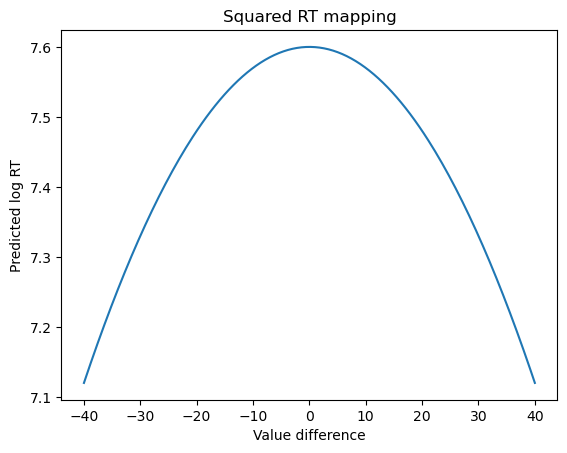

In [17]:
# Sanity check for the squared RT model

v_test = np.linspace(-40, 40, 200)

a_test = 7.6
b_test = 0.0003

mu_test = rt_location(
    v_test,
    a_test,
    b_test,
    rt_model="squared"
)

plt.plot(v_test, mu_test)
plt.xlabel("Value difference")
plt.ylabel("Predicted log RT")
plt.title("Squared RT mapping")
plt.show()

## Likelihood

I first define the choice and RT log-likelihoods separately. This
makes it easier to check the two modalities and later allows me to
fit the required choice-only baseline.

### Choice log-likelihood

For the logistic choice model, define

$$
\eta_i = \beta \Delta V_i.
$$

The choice log-likelihood is

$$
\ell_{choice}(k,\beta)
=
\sum_i
\left[
x_i\eta_i - \log(1 + \exp(\eta_i))
\right].
$$

In the code, `np.logaddexp(0, eta)` is used to calculate
$\log(1+\exp(\eta))$ without numerical overflow.

### RT log-likelihood

The RT log-likelihood is

$$
\ell_{RT}
=
\sum_i
\left[
-\frac{1}{2}\log(2\pi\sigma^2)
-
\frac{(\log RT_i-\mu_i)^2}{2\sigma^2}
\right].
$$

The mean $\mu_i$ is obtained from one of the three RT mappings.

In [18]:

def choice_log_likelihood(df, k, beta):
    choice = df["action(cleaned)"].to_numpy(dtype=float)

    v_imm, v_del, v_delta = hyperbolic_value(
        df["immOutcome"],
        df["delOutcome"],
        df["delay"],
        k
    )

    v_delta = np.asarray(v_delta, dtype=float)

    # Stable Bernoulli log-likelihood
    eta = beta * v_delta
    trial_log_likelihood = (choice*eta - np.logaddexp(0.0, eta)
    )

    return np.sum(trial_log_likelihood)

In [19]:
def rt_log_likelihood(df, k, a, b, sigma, rt_model):

    rt = df["RT"].to_numpy(dtype=float)

    if np.any(rt <= 0) or sigma <= 0:
        return -np.inf

    v_imm, v_del, v_delta = hyperbolic_value(df["immOutcome"], df["delOutcome"], df["delay"], k)

    v_delta = np.asarray(v_delta, dtype=float)
    mu_rt = rt_location(v_delta, a, b, rt_model)

    log_rt = np.log(rt)

    # Gaussian log-likelihood for log RT
    trial_log_likelihood = (-0.5 * np.log(2 * np.pi * sigma**2)- ((log_rt - mu_rt)**2) / (2 * sigma**2))

    return np.sum(trial_log_likelihood)

In [20]:
def choice_accuracy(df, k, beta):

    choice = df["action(cleaned)"].to_numpy(dtype=int)

    v_imm, v_del, v_delta = hyperbolic_value(
        df["immOutcome"],
        df["delOutcome"],
        df["delay"],
        k
    )

    v_delta = np.asarray(v_delta, dtype=float)

    p_imm, p_del = logistic_choice(v_delta, beta)

    predicted_choice = (p_imm >= 0.5).astype(int)

    return np.mean(predicted_choice == choice)

In [21]:
def joint_log_likelihood(df, k, beta, a, b, sigma, rt_model):
    choice_ll = choice_log_likelihood(df, k, beta)
    rt_ll = rt_log_likelihood(df, k, a, b, sigma, rt_model)

    return choice_ll + rt_ll

In [22]:
# penalize k and beta 
def l2_penalty(k, beta):

    scaled_k = np.log(k / K_CENTER)
    scaled_beta = np.log(beta / BETA_CENTER)

    return scaled_k**2 + scaled_beta**2


def negative_choice_log_likelihood(params, df, l2_lambda):
    k, beta = params

    choice_nll_per_trial = -choice_log_likelihood(df, k, beta) / len(df)

    penalty = l2_lambda * l2_penalty(k, beta)

    return choice_nll_per_trial + penalty


def negative_joint_log_likelihood(params, df, rt_model, l2_lambda):
    k, beta, a, b, sigma = params

    joint_ll = joint_log_likelihood(
        df=df,
        k=k,
        beta=beta,
        a=a,
        b=b,
        sigma=sigma,
        rt_model=rt_model
    )

    # add penalty for k and beta
    joint_nll_per_trial = -joint_ll / len(df)
    penalty = l2_lambda * l2_penalty(k, beta)

    return joint_nll_per_trial + penalty

In [23]:
def fit_with_starts(loss, starts, args, bounds):
    fits = []

    for start in starts:
        fit = minimize(loss, x0=start, args=args, method="L-BFGS-B", bounds=bounds, options={"maxiter": 2000})
        if fit.success:
            fits.append(fit)
    best_fit = min(fits, key=lambda fit: fit.fun)

    return best_fit

## Inference on Run A

In [24]:
# Global Constants

N_REPETITIONS = 50
SMALL_POSITIVE = 1e-6
BETA_UPPER_BOUND = 20

K_CENTER = 0.01
BETA_CENTER = 1.0

LAMBDA_VALUES = [
    0.0,
    0.0001,
    0.0003,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1
]

In [ ]:
rt_start_values = {
    "absolute": [7.6, 0.01, 0.4],
    "squared": [7.6, 0.0003, 0.4],
    "exponential": [7.3, 0.3, 0.4]
}

In [26]:
full_bounds = [
    (SMALL_POSITIVE, None),              # k
    (SMALL_POSITIVE, BETA_UPPER_BOUND),  # beta
    (None, None),                        # a
    (0, None),                           # b
    (SMALL_POSITIVE, None)               # sigma
]

In [27]:
# Starting values for the choice-only model

choice_start_values = [
    [0.001, 0.1],
    [0.01, 1.0],
    [0.1, 5.0]
]

choice_bounds = [(SMALL_POSITIVE, None), (SMALL_POSITIVE, BETA_UPPER_BOUND)]

In [28]:
# cross-validation to choose the best lambda for the choice-only model
def choose_l2_lambda(data):
    cv_rows = []

    for l2_lambda in LAMBDA_VALUES:
        total_validation_nll = 0
        total_validation_correct = 0
        total_validation_trials = 0

        print("Testing lambda:", l2_lambda)

        for participant_number, participant in enumerate(data):
            df = participant["train"].reset_index(drop=True)

            # Create 3 folds for cross-validation
            indices = np.arange(len(df))
            np.random.seed(1 + participant_number)
            np.random.shuffle(indices)
            folds = np.array_split(indices, 3)

            for fold_number in range(3):
                validation_index = folds[fold_number]

                training_index = np.concatenate([folds[index] for index in range(3) if index != fold_number])

                training_df = df.iloc[training_index]
                validation_df = df.iloc[validation_index]

                result = fit_with_starts(negative_choice_log_likelihood, choice_start_values, args=(training_df, l2_lambda), bounds=choice_bounds)

                k, beta = result.x

                validation_nll = -choice_log_likelihood(validation_df, k, beta)

                validation_accuracy = choice_accuracy(validation_df, k, beta)

                total_validation_nll += validation_nll
                total_validation_correct += validation_accuracy * len(validation_df)
                total_validation_trials += len(validation_df)

        cv_rows.append({
            "l2_lambda": l2_lambda,
            "validation_nll_per_trial": total_validation_nll / total_validation_trials,
            "validation_accuracy": total_validation_correct / total_validation_trials
        })

    cv_results = pd.DataFrame(cv_rows)

    best_index = cv_results["validation_nll_per_trial"].idxmin()

    best_lambda = float(cv_results.loc[best_index, "l2_lambda"])

    return cv_results, best_lambda


# Select one common lambda using Run A only
cv_results, best_lambda = choose_l2_lambda(data=cleaned_data)

display(cv_results)

print("Best lambda:", best_lambda)

Testing lambda: 0.0


C:\Users\Tony_Du\AppData\Local\Temp\ipykernel_98104\988445024.py:2: RuntimeWarning: overflow encountered in exp
  p_imm = 1 / (1 + np.exp(-beta * v_delta))


Testing lambda: 0.0001
Testing lambda: 0.0003
Testing lambda: 0.001
Testing lambda: 0.003
Testing lambda: 0.01
Testing lambda: 0.03
Testing lambda: 0.1


,l2_lambda,validation_nll_per_trial,validation_accuracy
0,0.0000,0.962693,0.862818
1,0.0001,0.906210,0.863381
2,0.0003,0.784564,0.864506
3,0.0010,0.702403,0.865294
4,0.0030,0.620378,0.865856
5,0.0100,0.543798,0.865631
6,0.0300,0.519913,0.865969
7,0.1000,0.567090,0.848188


Best lambda: 0.03


### Participant-level Run A fitting

I now apply the same Run A fitting procedure to all participants.
The fitted parameters are stored for later recovery, reliability and
Run B evaluation. Run B is not used during this inference step.

In [ ]:
# Fit the models for each participant and each run

def model_fitting(participant, run):
    df = participant[run]
    participant_id = participant["participant_id"]

    result_rows = []

    choice_only_result = fit_with_starts(negative_choice_log_likelihood, choice_start_values, args=(df, best_lambda), bounds=choice_bounds)
    choice_k, choice_beta = choice_only_result.x

    result_rows.append({
        "participant_id": participant_id,
        "model": "choice_only",
        "regularized_loss": choice_only_result.fun,
        "l2_lambda": best_lambda,
        "k": choice_k,
        "beta": choice_beta,
        "a": np.nan,
        "b": np.nan,
        "sigma": np.nan
    })

    # Fit the three regularized choice + RT models
    for rt_model, initial_params in rt_start_values.items():
        a_start, b_start, sigma_start = initial_params
        starting_values = [
            [0.001, 0.1, a_start, b_start, sigma_start],
            [0.01, 1.0, a_start, b_start, sigma_start],
            [0.1, 5.0, a_start, b_start, sigma_start]
        ]

        full_result = fit_with_starts(negative_joint_log_likelihood, starting_values, args=(df, rt_model, best_lambda), bounds=full_bounds)

        k, beta, a, b, sigma = full_result.x

        result_rows.append({
            "participant_id": participant_id,
            "model": rt_model,
            "regularized_loss": full_result.fun,
            "l2_lambda": best_lambda,
            "k": k,
            "beta": beta,
            "a": a,
            "b": b,
            "sigma": sigma
        })

    return pd.DataFrame(result_rows)

In [30]:
train_results = []

for index, participant in enumerate(cleaned_data):

    print("\nParticipant", index + 1)

    participant_result = model_fitting(participant, run="train")

    train_results.append(participant_result)

train_results_table = pd.concat(train_results, ignore_index=True)


Participant 1

Participant 2

Participant 3

Participant 4

Participant 5

Participant 6

Participant 7

Participant 8

Participant 9

Participant 10

Participant 11

Participant 12

Participant 13

Participant 14

Participant 15

Participant 16

Participant 17

Participant 18

Participant 19

Participant 20

Participant 21

Participant 22

Participant 23

Participant 24

Participant 25

Participant 26

Participant 27

Participant 28

Participant 29

Participant 30

Participant 31

Participant 32

Participant 33

Participant 34

Participant 35

Participant 36

Participant 37

Participant 38

Participant 39

Participant 40

Participant 41

Participant 42

Participant 43

Participant 44

Participant 45

Participant 46

Participant 47

Participant 48

Participant 49

Participant 50

Participant 51

Participant 52

Participant 53

Participant 54

Participant 55

Participant 56

Participant 57

Participant 58

Participant 59

Participant 60

Participant 61

Participant 62

Participant 63



In [31]:
train_results_table.groupby("model")["participant_id"].nunique()

parameter_summary = (
    train_results_table
    .groupby("model")[["k", "beta", "a", "b", "sigma"]]
    .agg(["min", "median", "max"])
)

parameter_summary

k                          beta                      \
                  min    median       max       min    median       max   
model                                                                     
absolute     0.000567  0.008308  0.063658  0.068407  0.578454  2.514140   
choice_only  0.000578  0.008056  0.058643  0.068139  0.577616  2.521912   
exponential  0.000529  0.009236  0.068088  0.067827  0.612480  2.534289   
squared      0.000570  0.008049  0.061249  0.068298  0.577616  2.517515   

                    a                        b                         sigma  \
                  min    median       max  min    median       max       min   
model                                                                          
absolute     6.755190  7.538179  8.039204  0.0  0.003777  0.017726  0.190266   
choice_only       NaN       NaN       NaN  NaN       NaN       NaN       NaN   
exponential  6.721009  7.434590  7.915629  0.0  0.202507  0.829370  0.190269   
squared      6.743212  7.512189  8.016027  0.0  0.000039  0.000326  0.190266   

                                 
               median       max  
model                            
absolute     0.321553  0.526946  
choice_only       NaN       NaN  
exponential  0.315915  0.506314  
squared      0.324421  0.526946

In [32]:
# Check how many participants have beta at the upper bound

train_results_table["beta_at_bound"] = np.isclose(train_results_table["beta"], BETA_UPPER_BOUND)

beta_bound_counts = (train_results_table .groupby("model")["beta_at_bound"] .sum()
)

beta_bound_counts

model
absolute       0
choice_only    0
exponential    0
squared        0
Name: beta_at_bound, dtype: int64

## Parameter recovery

Parameter recovery checks whether the fitting procedure can recover
the parameter values used to generate simulated data. These generating
values are chosen before the simulation and are therefore known. They
are not the known psychological parameters of a real participant.

For each RT model, I use observed Run A trial designs from different
participants and simulate new choices and RTs. I use parameter values covering low,
medium, and high ranges and repeat each condition several times. Each
simulated data set is fitted with both the choice-only model and the
corresponding full choice + RT model.

I compare recovery of `k` and `beta` between the two fits and examine
recovery of the RT parameters `a`, `b`, and `sigma`. This assesses
practical parameter recovery under the current finite data set. It is
not a proof of structural identifiability.

In [33]:
def simulate_data(data, k, beta, a, b, sigma, rt_model):
    syn_data = data.copy()
    v_imm, v_del, v_delta = hyperbolic_value(
        syn_data["immOutcome"],
        syn_data["delOutcome"],
        syn_data["delay"],
        k
 )

    v_delta = np.asarray(v_delta, dtype=float)

    # Simulate choices from the logistic choice rule
    syn_p_imm, syn_p_del = logistic_choice(v_delta, beta)
    syn_choice = np.random.binomial(n=1, p=syn_p_imm)

    # Simulate log RT from the specified RT model
    syn_mu_rt = rt_location(v_delta, a, b, rt_model)
    syn_log_rt = np.random.normal(loc=syn_mu_rt, scale=sigma)

    syn_rt = np.exp(syn_log_rt)

    syn_data["action(cleaned)"] = syn_choice
    syn_data["RT"] = syn_rt

    return syn_data

In [ ]:
def run_recovery(rt_model, params, data):
    
    initial_params = rt_start_values[rt_model]
    idx = np.random.choice(len(data), size=N_REPETITIONS, replace=False)

    a_start, b_start, sigma_start = initial_params
    recovery_start_values = [
        [0.001, 0.1, a_start, b_start, sigma_start],
        [0.01, 1.0, a_start, b_start, sigma_start],
        [0.1, 5.0, a_start, b_start, sigma_start]
    ]

    recovery_rows = []

    for param in params:
        print("Generating parameters:", param["parameter_range"], rt_model)

        for repetition in range(1, N_REPETITIONS + 1):

            run_index = int(idx[repetition - 1])
            run_participant = data[run_index]
            run_data = run_participant["train"]
            syn_data = simulate_data(
                run_data,
                param["k"],
                param["beta"],
                param["a"],
                param["b"],
                param["sigma"],
                rt_model
            )
            choice_fit = fit_with_starts(negative_choice_log_likelihood, choice_start_values, args=(syn_data, best_lambda), bounds=choice_bounds)

            full_fit = fit_with_starts(negative_joint_log_likelihood, recovery_start_values, args=(syn_data, rt_model, best_lambda), bounds=full_bounds)

            recovery_rows.append({
                "model": rt_model,
                "parameter_range": param["parameter_range"],
                "true_k": param["k"],
                "choice_k": choice_fit.x[0],
                "full_k": full_fit.x[0],
                "true_beta": param["beta"],
                "choice_beta": choice_fit.x[1],
                "full_beta": full_fit.x[1],
                "true_a": param["a"],
                "full_a": full_fit.x[2],
                "true_b": param["b"],
                "full_b": full_fit.x[3],
                "true_sigma": param["sigma"],
                "full_sigma": full_fit.x[4],
            })

    recovery_results = pd.DataFrame(recovery_rows)

    # Relative recovery errors
    recovery_results["choice_k_error"] = np.abs(recovery_results["choice_k"] - recovery_results["true_k"]) / recovery_results["true_k"]
    recovery_results["full_k_error"] = np.abs(recovery_results["full_k"] - recovery_results["true_k"]) / recovery_results["true_k"]

    recovery_results["choice_beta_error"] = np.abs(recovery_results["choice_beta"] - recovery_results["true_beta"]) / recovery_results["true_beta"]
    recovery_results["full_beta_error"] = np.abs(recovery_results["full_beta"] - recovery_results["true_beta"]) / recovery_results["true_beta"]

    recovery_results["a_error"] = np.abs(recovery_results["full_a"] - recovery_results["true_a"]) / recovery_results["true_a"]
    recovery_results["b_error"] = np.abs(recovery_results["full_b"] - recovery_results["true_b"]) / recovery_results["true_b"]
    recovery_results["sigma_error"] = np.abs(recovery_results["full_sigma"] - recovery_results["true_sigma"]) / recovery_results["true_sigma"]

    recovery_results["k_improvement"] = recovery_results["choice_k_error"] - recovery_results["full_k_error"]
    recovery_results["beta_improvement"] = recovery_results["choice_beta_error"] - recovery_results["full_beta_error"]
    recovery_results["b_at_zero"] = np.isclose(recovery_results["full_b"], 0)

    return recovery_results

### Recovery for the squared RT model

I first examine parameter recovery for the squared RT model. The
observed Run A estimates are used only to select approximately
realistic generating parameter ranges.

In [35]:
squared_fitted_parameters = train_results_table.loc[train_results_table["model"] == "squared", ["k", "beta", "a", "b", "sigma"]]

squared_fitted_parameters.quantile([0.10, 0.50, 0.90])

,k,beta,a,b,sigma
0.1,0.000955,0.204102,7.159126,0.000000,0.250984
0.5,0.008049,0.577616,7.512189,0.000039,0.324421
0.9,0.025268,1.855696,7.777314,0.000150,0.419416


In [36]:
squared_parameters = [
    {
        "parameter_range": "low",
        "k": 0.001,
        "beta": 0.3,
        "a": 7.2,
        "b": 0.00002,
        "sigma": 0.25
    },
    {
        "parameter_range": "medium",
        "k": 0.01,
        "beta": 1.0,
        "a": 7.5,
        "b": 0.00005,
        "sigma": 0.35
    },
    {
        "parameter_range": "high",
        "k": 0.025,
        "beta": 2.0,
        "a": 7.8,
        "b": 0.00015,
        "sigma": 0.42
    }
]

In [37]:
np.random.seed(1)

squared_recovery_results = run_recovery("squared", squared_parameters, cleaned_data)

squared_recovery_results.head()

Generating parameters: low squared
Generating parameters: medium squared
Generating parameters: high squared


,model,parameter_range,true_k,choice_k,full_k,true_beta,choice_beta,full_beta,true_a,full_a,...,choice_k_error,full_k_error,choice_beta_error,full_beta_error,a_error,b_error,sigma_error,k_improvement,beta_improvement,b_at_zero
0,squared,low,0.001,0.002101,0.002020,0.3,0.364828,0.372398,7.2,7.212374,...,1.101057,1.020470,0.216092,0.241328,0.001719,1.284102,0.135717,0.080587,-0.025236,False
1,squared,low,0.001,0.001196,0.001230,0.3,0.538870,0.524462,7.2,7.251437,...,0.196320,0.229708,0.796232,0.748208,0.007144,0.539930,0.111529,-0.033388,0.048024,False
2,squared,low,0.001,0.001685,0.001685,0.3,0.361553,0.361553,7.2,7.235080,...,0.685030,0.685025,0.205176,0.205178,0.004872,1.000000,0.095889,0.000006,-0.000002,True
3,squared,low,0.001,0.001219,0.001221,0.3,0.461744,0.461265,7.2,7.221177,...,0.219359,0.220815,0.539146,0.537551,0.002941,0.795245,0.086910,-0.001456,0.001595,False
4,squared,low,0.001,0.001330,0.001310,0.3,0.407262,0.411866,7.2,7.209903,...,0.329560,0.310456,0.357539,0.372888,0.001375,0.636683,0.000374,0.019104,-0.015350,False


## Absolute recovery

In [38]:
absolute_fitted_parameters = train_results_table.loc[train_results_table["model"] == "absolute",["k", "beta", "a", "b", "sigma"]]

absolute_fitted_parameters.quantile([0.10, 0.50, 0.90])

,k,beta,a,b,sigma
0.1,0.000952,0.202789,7.170446,0.000000,0.249176
0.5,0.008308,0.578454,7.538179,0.003777,0.321553
0.9,0.025099,1.863745,7.810286,0.007314,0.419282


In [39]:
absolute_parameters = [
    {
        "parameter_range": "low",
        "k": 0.001,
        "beta": 0.3,
        "a": 7.2,
        "b": 0.001,
        "sigma": 0.25
    },
    {
        "parameter_range": "medium",
        "k": 0.01,
        "beta": 1.0,
        "a": 7.5,
        "b": 0.004,
        "sigma": 0.35
    },
    {
        "parameter_range": "high",
        "k": 0.025,
        "beta": 2.0,
        "a": 7.8,
        "b": 0.007,
        "sigma": 0.4
    }
]

In [40]:
np.random.seed(1)

absolute_recovery_results = run_recovery("absolute", absolute_parameters, cleaned_data)

absolute_recovery_results.head()

Generating parameters: low absolute
Generating parameters: medium absolute
Generating parameters: high absolute


,model,parameter_range,true_k,choice_k,full_k,true_beta,choice_beta,full_beta,true_a,full_a,...,choice_k_error,full_k_error,choice_beta_error,full_beta_error,a_error,b_error,sigma_error,k_improvement,beta_improvement,b_at_zero
0,absolute,low,0.001,0.002101,0.002042,0.3,0.364828,0.370344,7.2,7.222077,...,1.101057,1.041858,0.216092,0.234480,0.003066,1.724131,0.135484,0.059199,-0.018388,False
1,absolute,low,0.001,0.001196,0.001208,0.3,0.538870,0.533960,7.2,7.251030,...,0.196320,0.207560,0.796232,0.779868,0.007087,0.415066,0.109222,-0.011241,0.016365,False
2,absolute,low,0.001,0.001685,0.001685,0.3,0.361553,0.361554,7.2,7.231582,...,0.685030,0.685026,0.205176,0.205178,0.004386,1.000000,0.095939,0.000005,-0.000003,True
3,absolute,low,0.001,0.001219,0.001220,0.3,0.461744,0.461630,7.2,7.218888,...,0.219359,0.219699,0.539146,0.538766,0.002623,0.963401,0.088751,-0.000340,0.000381,False
4,absolute,low,0.001,0.001330,0.001314,0.3,0.407262,0.410915,7.2,7.207509,...,0.329560,0.314396,0.357539,0.369717,0.001043,0.312860,0.002600,0.015164,-0.012179,False


# Exponential recovery

In [41]:
exponential_fitted_parameters = train_results_table.loc[train_results_table["model"] == "exponential", ["k", "beta", "a", "b", "sigma"]]

exponential_fitted_parameters.quantile([0.10, 0.50, 0.90])

,k,beta,a,b,sigma
0.1,0.000955,0.204348,7.105026,0.000000,0.240582
0.5,0.009236,0.612480,7.434590,0.202507,0.315915
0.9,0.026968,1.994781,7.660082,0.406141,0.404912


In [42]:
exponential_parameters = [
    {
        "parameter_range": "low",
        "k": 0.001,
        "beta": 0.3,
        "a": 7.2,
        "b": 0.05,
        "sigma": 0.25
    },
    {
        "parameter_range": "medium",
        "k": 0.01,
        "beta": 1.0,
        "a": 7.5,
        "b": 0.2,
        "sigma": 0.35
    },
    {
        "parameter_range": "high",
        "k": 0.025,
        "beta": 2.0,
        "a": 7.8,
        "b": 0.4,
        "sigma": 0.4
    }
]

In [43]:
np.random.seed(1)

exponential_recovery_results = run_recovery("exponential", exponential_parameters, cleaned_data)

exponential_recovery_results.head()

Generating parameters: low exponential
Generating parameters: medium exponential
Generating parameters: high exponential


,model,parameter_range,true_k,choice_k,full_k,true_beta,choice_beta,full_beta,true_a,full_a,...,choice_k_error,full_k_error,choice_beta_error,full_beta_error,a_error,b_error,sigma_error,k_improvement,beta_improvement,b_at_zero
0,exponential,low,0.001,0.002101,0.002014,0.3,0.364828,0.373072,7.2,7.188253,...,1.101057,1.013535,0.216092,0.243572,0.001632,2.235320,0.139653,0.087522,-2.748033e-02,False
1,exponential,low,0.001,0.001196,0.001136,0.3,0.538870,0.565843,7.2,7.253990,...,0.196320,0.135798,0.796232,0.886144,0.007499,0.328376,0.109593,0.060521,-8.991164e-02,False
2,exponential,low,0.001,0.001685,0.001685,0.3,0.361553,0.361553,7.2,7.257853,...,0.685030,0.685028,0.205176,0.205177,0.008035,1.000000,0.107809,0.000003,-9.956414e-07,True
3,exponential,low,0.001,0.001219,0.001225,0.3,0.461744,0.459964,7.2,7.215487,...,0.219359,0.224785,0.539146,0.533214,0.002151,1.287352,0.081486,-0.005426,5.932004e-03,False
4,exponential,low,0.001,0.001330,0.001338,0.3,0.407262,0.405170,7.2,7.210860,...,0.329560,0.338359,0.357539,0.350567,0.001508,0.150672,0.000006,-0.008799,6.971617e-03,False


In [44]:
all_recovery_results = pd.concat([squared_recovery_results, absolute_recovery_results, exponential_recovery_results], ignore_index=True)

In [45]:
choice_parameter_recovery = (all_recovery_results.groupby(["model", "parameter_range"])[
        ["choice_k_error", "full_k_error", "choice_beta_error", "full_beta_error"]
        ].mean() * 100
)

choice_parameter_recovery

choice_k_error  full_k_error  choice_beta_error  \
model       parameter_range                                                    
absolute    high                  23.007886     21.942582          18.015323   
            low                   73.900229     73.767503          34.160574   
            medium                 5.232983      5.150010          16.211966   
exponential high                  23.007886     20.362498          18.015323   
            low                   73.900229     71.352569          34.160574   
            medium                 5.232983      4.362510          16.211966   
squared     high                  23.007886     20.219380          18.015323   
            low                   73.900229     73.688944          34.160574   
            medium                 5.232983      5.131278          16.211966   

                             full_beta_error  
model       parameter_range                   
absolute    high                   18.485397  
            low                    34.051654  
            medium                 16.170821  
exponential high                   18.609167  
            low                    35.249212  
            medium                 16.092877  
squared     high                   18.937379  
            low                    34.076044  
            medium                 16.274883

In [46]:
rt_parameter_recovery = (all_recovery_results.groupby(["model", "parameter_range"])[
        ["a_error", "b_error", "sigma_error"]
        ].mean() * 100
)

display(rt_parameter_recovery)

a_error     b_error  sigma_error
model       parameter_range                                   
absolute    high             0.545543   34.222974     5.515299
            low              0.309586  107.921376     7.000681
            medium           0.458703   56.197127     5.685333
exponential high             0.555274   49.421610     5.532684
            low              0.317014  103.823493     6.857523
            medium           0.520235   36.194569     5.629965
squared     high             0.527695   38.348878     5.564134
            low              0.278137  108.323695     7.026253
            medium           0.412479   86.616741     5.645476

In [47]:
recovery_improvement = (all_recovery_results.groupby(["model", "parameter_range"])[
        ["k_improvement", "beta_improvement"]
        ].mean() * 100
)

recovery_improvement

k_improvement  beta_improvement
model       parameter_range                                 
absolute    high                  1.065304         -0.470074
            low                   0.132726          0.108920
            medium                0.082973          0.041146
exponential high                  2.645388         -0.593844
            low                   2.547660         -1.088638
            medium                0.870473          0.119089
squared     high                  2.788506         -0.922056
            low                   0.211285          0.084531
            medium                0.101705         -0.062917

In [48]:
recovery_boundaries = (all_recovery_results.groupby(["model", "parameter_range"])[["b_at_zero"]].mean())

recovery_boundaries

b_at_zero
model       parameter_range           
absolute    high                  0.00
            low                   0.36
            medium                0.08
exponential high                  0.08
            low                   0.32
            medium                0.00
squared     high                  0.02
            low                   0.38
            medium                0.18

## Reliability

In [49]:
run_b_result_tables = []

for index, participant in enumerate(cleaned_data):

    print("\nRun B participant", index + 1)
    participant_result = model_fitting(participant,run="test")

    run_b_result_tables.append(participant_result)

run_b_reliability_results = pd.concat(run_b_result_tables, ignore_index=True)



Run B participant 1

Run B participant 2

Run B participant 3

Run B participant 4

Run B participant 5

Run B participant 6

Run B participant 7

Run B participant 8

Run B participant 9

Run B participant 10

Run B participant 11

Run B participant 12

Run B participant 13

Run B participant 14

Run B participant 15

Run B participant 16

Run B participant 17

Run B participant 18

Run B participant 19

Run B participant 20

Run B participant 21

Run B participant 22

Run B participant 23

Run B participant 24

Run B participant 25

Run B participant 26

Run B participant 27

Run B participant 28

Run B participant 29

Run B participant 30

Run B participant 31

Run B participant 32

Run B participant 33

Run B participant 34

Run B participant 35

Run B participant 36

Run B participant 37

Run B participant 38

Run B participant 39

Run B participant 40

Run B participant 41

Run B participant 42

Run B participant 43

Run B participant 44

Run B participant 45

Run B participant 

In [50]:
# Merge Run A and Run B results for reliability analysis

reliability_a_b = train_results_table.merge(run_b_reliability_results, on=["participant_id", "model"], suffixes=("_run_a", "_run_b"))

reliability_a_b.head()

,participant_id,model,regularized_loss_run_a,l2_lambda_run_a,k_run_a,beta_run_a,a_run_a,b_run_a,sigma_run_a,beta_at_bound,regularized_loss_run_b,l2_lambda_run_b,k_run_b,beta_run_b,a_run_b,b_run_b,sigma_run_b
0,1,choice_only,0.495505,0.03,0.012110,0.397185,NaN,NaN,NaN,False,0.554700,0.03,0.020489,0.360860,NaN,NaN,NaN
1,1,absolute,1.045001,0.03,0.011871,0.398715,7.588446,0.004505,0.419161,False,1.187145,0.03,0.018527,0.354858,7.699923,0.027359,0.454365
2,1,squared,1.045241,0.03,0.011882,0.398646,7.574122,0.000129,0.419264,False,1.197265,0.03,0.019949,0.359720,7.615313,0.001307,0.459996
3,1,exponential,1.043523,0.03,0.010623,0.402812,7.517364,0.139613,0.417441,False,1.190376,0.03,0.017885,0.351691,7.532675,0.338068,0.454957
4,2,choice_only,0.169035,0.03,0.012201,1.741171,NaN,NaN,NaN,False,0.413561,0.03,0.018108,1.107790,NaN,NaN,NaN


In [51]:
rel_rows = []

for model in ["choice_only", "absolute", "squared", "exponential"]:
    model_data = reliability_a_b[reliability_a_b["model"] == model]
    params = ["k", "beta"] if model == "choice_only" else ["k", "beta", "a", "b", "sigma"]

    for param in params:
        run_a = model_data[param + "_run_a"]
        run_b = model_data[param + "_run_b"]

        mae = np.mean(np.abs(run_a - run_b))

        rel_rows.append({
            "model": model,
            "parameter": param,
            "mae": mae
        })

reliability_results = pd.DataFrame(rel_rows)
reliability_results

,model,parameter,mae
0,choice_only,k,0.008331
1,choice_only,beta,0.478168
2,absolute,k,0.008381
3,absolute,beta,0.517917
4,absolute,a,0.189178
5,absolute,b,0.017356
6,absolute,sigma,0.056257
7,squared,k,0.008451
8,squared,beta,0.515199
9,squared,a,0.186186


In [52]:
choice_parameter_reliability = (
    reliability_results[reliability_results["parameter"].isin(["k", "beta"])].pivot(
        index="model",
        columns="parameter",
        values="mae"
    )
)

choice_parameter_reliability

parameter,beta,k
model,,
absolute,0.517917,0.008381
choice_only,0.478168,0.008331
exponential,0.532879,0.009282
squared,0.515199,0.008451


In [53]:
rt_parameter_reliability = (reliability_results[reliability_results["parameter"].isin(["a", "b", "sigma"])].pivot(
        index="model",
        columns="parameter",
        values="mae"
    )
)

rt_parameter_reliability

parameter,a,b,sigma
model,,,
absolute,0.189178,0.017356,0.056257
exponential,0.172920,7.484031,0.057534
squared,0.186186,0.005559,0.055857


In [54]:
reliability_a_b["beta_at_bound_run_a"] = np.isclose(reliability_a_b["beta_run_a"], BETA_UPPER_BOUND)
reliability_a_b["beta_at_bound_run_b"] = np.isclose(reliability_a_b["beta_run_b"], BETA_UPPER_BOUND)

reliability_a_b["b_at_zero_run_a"] = np.isclose(reliability_a_b["b_run_a"], 0)
reliability_a_b["b_at_zero_run_b"] = np.isclose(reliability_a_b["b_run_b"], 0)

reliability_boundary_summary = (reliability_a_b.groupby("model")[
        [
            "beta_at_bound_run_a",
            "beta_at_bound_run_b",
            "b_at_zero_run_a",
            "b_at_zero_run_b"
        ]
    ].mean()
)

display(reliability_boundary_summary)

,beta_at_bound_run_a,beta_at_bound_run_b,b_at_zero_run_a,b_at_zero_run_b
model,,,,
absolute,0.0,0.0,0.141414,0.363636
choice_only,0.0,0.0,0.000000,0.000000
exponential,0.0,0.0,0.141414,0.161616
squared,0.0,0.0,0.191919,0.383838


## Out-of-sample evaluation on Run B

In [55]:
test_data = {participant["participant_id"]: participant["test"] for participant in cleaned_data}

choice_ll_test = []
choice_acc_test = []
rt_ll_test = []

for _, row in train_results_table.iterrows():
    data = test_data[int(row["participant_id"])]
    k = row["k"]
    beta = row["beta"]

    choice_ll_test.append(choice_log_likelihood(data, k, beta))
    choice_acc_test.append(choice_accuracy(data, k, beta))

    if row["model"] == "choice_only":
        rt_ll_test.append(np.nan)
    else:
        rt_ll_test.append(rt_log_likelihood(data, k, row["a"], row["b"], row["sigma"], row["model"]))

train_results_table["test_choice_ll"] = choice_ll_test
train_results_table["test_choice_accuracy"] = choice_acc_test
train_results_table["test_rt_ll"] = rt_ll_test

In [56]:
# Compare each RT model with the choice-only baseline

baseline = train_results_table[train_results_table["model"] == "choice_only"].set_index("participant_id")

baseline_ll = baseline["test_choice_ll"]
baseline_acc = baseline["test_choice_accuracy"]

train_results_table["choice_ll_difference"] = (train_results_table["test_choice_ll"] - train_results_table["participant_id"].map(baseline_ll))

train_results_table["accuracy_difference"] = (train_results_table["test_choice_accuracy"] - train_results_table["participant_id"].map(baseline_acc))

test_trial_counts = {participant["participant_id"]: len(participant["test"]) for participant in cleaned_data}

train_results_table["n_test"] = (train_results_table["participant_id"].map(test_trial_counts))
train_results_table["test_choice_ll_per_trial"] = (train_results_table["test_choice_ll"] / train_results_table["n_test"])
train_results_table["test_rt_ll_per_trial"] = (train_results_table["test_rt_ll"] / train_results_table["n_test"])

train_results_table.head(10)

,participant_id,model,regularized_loss,l2_lambda,k,beta,a,b,sigma,beta_at_bound,test_choice_ll,test_choice_accuracy,test_rt_ll,choice_ll_difference,accuracy_difference,n_test,test_choice_ll_per_trial,test_rt_ll_per_trial
0,1,choice_only,0.495505,0.03,0.012110,0.397185,NaN,NaN,NaN,False,-107.370717,0.757062,NaN,0.000000,0.000000,177,-0.606614,NaN
1,1,absolute,1.045001,0.03,0.011871,0.398715,7.588446,0.004505,0.419161,False,-108.591053,0.762712,-115.607742,-1.220336,0.005650,177,-0.613509,-0.653151
2,1,squared,1.045241,0.03,0.011882,0.398646,7.574122,0.000129,0.419264,False,-108.532161,0.762712,-116.568737,-1.161444,0.005650,177,-0.613176,-0.658580
3,1,exponential,1.043523,0.03,0.010623,0.402812,7.517364,0.139613,0.417441,False,-115.717656,0.762712,-116.154498,-8.346938,0.005650,177,-0.653772,-0.656240
4,2,choice_only,0.169035,0.03,0.012201,1.741171,NaN,NaN,NaN,False,-83.058324,0.933333,NaN,0.000000,0.000000,180,-0.461435,NaN
5,2,absolute,0.571260,0.03,0.012186,1.744766,7.485342,0.005450,0.361782,False,-83.174990,0.933333,-604.795002,-0.116666,0.000000,180,-0.462083,-3.359972
6,2,squared,0.568122,0.03,0.012471,1.683859,7.471988,0.000184,0.360591,False,-81.305228,0.933333,-597.901295,1.753096,0.000000,180,-0.451696,-3.321674
7,2,exponential,0.580992,0.03,0.011993,1.790113,7.442014,0.019908,0.365279,False,-84.720396,0.922222,-570.483332,-1.662073,-0.011111,180,-0.470669,-3.169352
8,3,choice_only,0.221233,0.03,0.004300,1.292843,NaN,NaN,NaN,False,-536.375336,0.544444,NaN,0.000000,0.000000,180,-2.979863,NaN
9,3,absolute,0.219845,0.03,0.004268,1.295782,7.912028,0.000747,0.241634,False,-533.928437,0.544444,-55.551772,2.446898,0.000000,180,-2.966269,-0.308621


In [57]:
train_results_table["choice_ll_difference_per_trial"] = (train_results_table["choice_ll_difference"] / train_results_table["n_test"])

group_comparison = (
    train_results_table.groupby("model").agg(
        mean_choice_ll_per_trial=("test_choice_ll_per_trial", "mean"),
        median_choice_ll_per_trial=("test_choice_ll_per_trial", "median"),
        mean_choice_accuracy=("test_choice_accuracy", "mean"),
        mean_choice_ll_difference=("choice_ll_difference_per_trial", "mean"),
        mean_accuracy_difference=("accuracy_difference", "mean"),
        mean_rt_ll_per_trial=("test_rt_ll_per_trial", "mean"),
        median_rt_ll_per_trial=("test_rt_ll_per_trial", "median")
    )
)
group_comparison

,mean_choice_ll_per_trial,median_choice_ll_per_trial,mean_choice_accuracy,mean_choice_ll_difference,mean_accuracy_difference,mean_rt_ll_per_trial,median_rt_ll_per_trial
model,,,,,,,
absolute,-1.087894,-0.751962,0.684539,0.009731,0.002359,-0.891038,-0.550971
choice_only,-1.097625,-0.761612,0.682180,0.000000,0.000000,NaN,NaN
exponential,-1.162032,-0.765857,0.662010,-0.064407,-0.020169,-0.933112,-0.574275
squared,-1.090241,-0.751978,0.683641,0.007384,0.001461,-0.876608,-0.546792


In [58]:
full_model_results = train_results_table[
    train_results_table["model"] != "choice_only"
]

In [59]:
best_rt_rows = full_model_results.loc[full_model_results.groupby("participant_id")["test_rt_ll_per_trial"].idxmax()]

best_rt_counts = (best_rt_rows["model"].value_counts())

best_rt_counts

model
squared        44
exponential    35
absolute       20
Name: count, dtype: int64

In [60]:
choice_test_summary = (full_model_results.groupby("model").agg(
        mean_ll_difference=("choice_ll_difference_per_trial", "mean"),
        better_ll=("choice_ll_difference", lambda x: (x > 0).sum()),

        mean_accuracy_difference=("accuracy_difference", "mean"),
        better_accuracy=("accuracy_difference", lambda x: (x > 0).sum())
        )
)

choice_test_summary

,mean_ll_difference,better_ll,mean_accuracy_difference,better_accuracy
model,,,,
absolute,0.009731,46,0.002359,24
exponential,-0.064407,34,-0.020169,22
squared,0.007384,59,0.001461,18


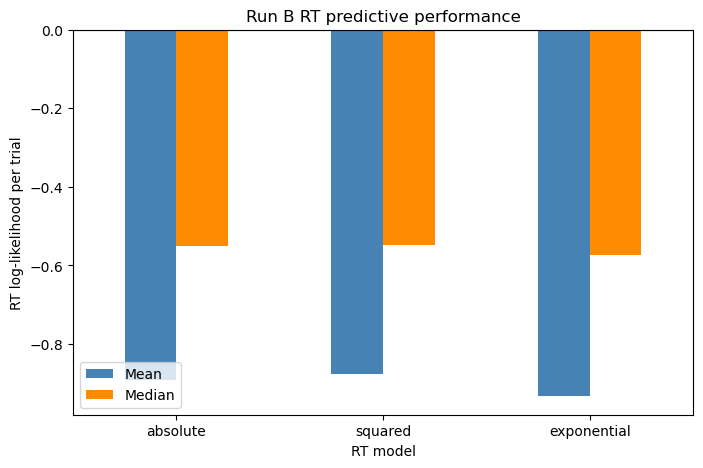

In [61]:
model_names = [
    "absolute",
    "squared",
    "exponential"
]

rt_scores = (
    full_model_results
    .groupby("model")[
        "test_rt_ll_per_trial"
    ]
    .agg(["mean", "median"])
    .loc[model_names]
)
rt_scores.columns = ["Mean", "Median"]

rt_scores.plot(
    kind="bar",
    figsize=(8, 5),
    color=[
        "steelblue",
        "darkorange"
    ]
)

plt.axhline(
    0,
    color="black"
)

plt.xlabel("RT model")
plt.ylabel("RT log-likelihood per trial")
plt.title("Run B RT predictive performance")

plt.xticks(rotation=0)
plt.show()